# Analisis Sentimen Dinamika Respons Masyarakat di X terhadap Isu Kekerasan Seksual di Lingkungan Kampus — Studi Kasus FH UI
### Metodologi CRISP-DM | Klasik (NB/SVM/LogReg/XGB) + BiLSTM | Explainable AI (SHAP) | Deployment (Streamlit + ngrok)

---
## Fase 1 — Business Understanding

**1.1 Latar Belakang & Tujuan.**
Media sosial X menjadi ruang utama wacana publik atas kasus kekerasan seksual (KS) di kampus. Respons masyarakat terpolarisasi dan berdinamika seiring waktu. Penelitian ini membangun model *machine learning* untuk mengklasifikasikan sentimen tweet secara otomatis, lalu **menjelaskan** keputusan model (XAI)

**1.2 Definisi Operasional Label.**
- **Positive (1)** — Mendukung korban, mendesak keadilan (*"Salut korban berani speak up, usut tuntas!"*).
- **Negative (2)** — *Victim blaming*, membela terlapor (*"Kenapa baru lapor? Cari sensasi aja."*).
- **Neutral (0)** — Informatif/kronologi tanpa opini (*"Rektorat merilis pernyataan resmi terkait kasus."*).

**1.3 Sumber Label.** Pelabelan awal dilakukan dengan LLM (GPT) lalu **diverifikasi manusia** (kolom `validasi_h1`). Kolom `sentimen` (label mentah pra-verifikasi) dipakai sebagai pembanding untuk mengukur *annotation agreement* (lihat Fase 2).

**1.4 Research Questions.**
1. Seberapa baik model klasik membedakan sentimen sensitif ini, dan apakah model kontekstual diperlukan?
2. Kata/fitur apa yang paling menentukan tiap kelas (XAI)?

**1.5 Metrik Evaluasi.**
Distribusi kelas *imbalanced* (rasio ~9:1). Metrik utama: **F1-macro** (memberi bobot setara ke kelas minoritas, sejalan dengan kepentingan mendeteksi kelas **Negative**). Metrik pendukung: **F1-weighted**, **F1 kelas Negative**, dan **akurasi**. Pemilihan model dilakukan **murni via cross-validation pada data latih**

**1.6 Keterbatasan** Dataset kecil (~1.3k baris) dan sangat timpang (Negative paling langka). Akibatnya estimasi metrik kelas Negative pada *test set* berderajat ketidakpastian tinggi.

## Fase 0 — Setup & Konfigurasi

In [2]:
%pip install -q "numpy<2.3" pandas matplotlib seaborn scikit-learn "imbalanced-learn>=0.12" nltk PySastrawi shap joblib wordcloud rapidfuzz xgboost networkx plotly

import os, re, string, warnings, joblib, itertools
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# ── Konfigurasi kolom & label ─────────────────────────────────────────────────
DATA_PATH = "dataset_final.csv"
COL_TIME, COL_TEXT, COL_LABEL = "createdAt", "text", "validasi_h1"
COL_RAWLABEL = "sentimen"

LABEL_ORDER  = [0, 1, 2]
ID2LABEL     = {0: "Neutral", 1: "Positive", 2: "Negative"}
LABEL2ID     = {v: k for k, v in ID2LABEL.items()}
SENT_COLORS  = {0: "#7f7f7f", 1: "#1f77b4", 2: "#d62728"}
PALETTE      = [SENT_COLORS[l] for l in LABEL_ORDER]

import nltk
for _pkg in ["stopwords", "punkt", "punkt_tab"]:
    try: nltk.download(_pkg, quiet=True)
    except Exception: pass

print("Setup selesai. Mapping label:", ID2LABEL)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.8 MB/s eta 0:00:00
Setup selesai. Mapping label: {0: 'Neutral', 1: 'Positive', 2: 'Negative'}


---
## Fase 2 — Data Understanding (EDA)
### 2a. Pemuatan, Inspeksi, Deduplikasi, Distribusi Label & Agreement

Shape awal: (1291, 4)
Kolom     : ['createdAt', 'text', 'sentimen', 'validasi_h1']


,createdAt,text,sentimen,validasi_h1
0,2026-04-12 03:20:25,@DennySeggssegar @sampahfhui jangan shift the ...,Positive,1
1,2026-04-12 03:50:12,"DOWNFALL ERA, bayangin lu dikasih anugerah mas...",Positive,1
2,2026-04-12 03:56:44,gue pernah ke fhui buat edukasi mrk soal KS wa...,Positive,1



Tipe data:
 createdAt      object
text           object
sentimen       object
validasi_h1     int64
dtype: object

Missing values:
 createdAt      0
text           0
sentimen       0
validasi_h1    0
dtype: int64

Exact duplicates: 0
Mendeteksi near-duplicate (threshold >= 90%)...
Near-duplicate dihapus: 28 baris  ->  shape: (1263, 4)


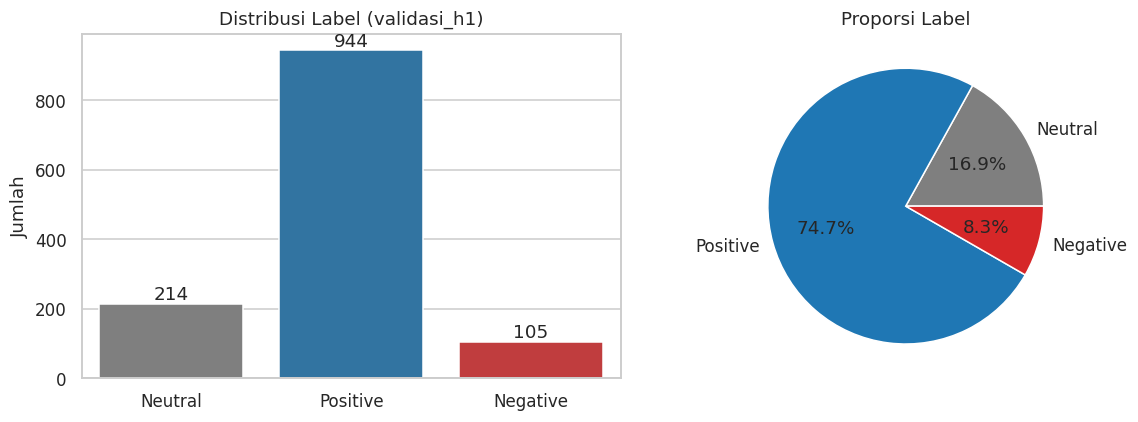

Imbalance ratio (maks:min) = 8.99 : 1


In [3]:
# ── Pemuatan data (TANPA dummy generator) ─────────────────────────────────────
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"'{DATA_PATH}' tidak ditemukan. Letakkan dataset_final.csv di direktori notebook.")

df = pd.read_csv(DATA_PATH, encoding="utf-8")
print("Shape awal:", df.shape)
print("Kolom     :", list(df.columns))

# Validasi kolom wajib
for c in (COL_TIME, COL_TEXT, COL_LABEL):
    assert c in df.columns, f"Kolom wajib '{c}' tidak ada di dataset."

df[COL_LABEL] = df[COL_LABEL].astype(int)
assert set(df[COL_LABEL].unique()).issubset(set(LABEL_ORDER)), \
    f"Label di {COL_LABEL} harus subset {LABEL_ORDER}, ditemukan {sorted(df[COL_LABEL].unique())}"

display(df.head(3))
print("\nTipe data:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())

# ── Deduplikasi ───────────────────────────────────────────────────────────────
exact_dup = df[COL_TEXT].duplicated().sum()
print(f"\nExact duplicates: {exact_dup}")
df = (df.drop_duplicates(subset=[COL_TEXT])
        .dropna(subset=[COL_TEXT, COL_LABEL])
        .reset_index(drop=True))

# Near-duplicate (rapidfuzz >= 90). O(n^2)
from rapidfuzz import fuzz as rfuzz
print("Mendeteksi near-duplicate (threshold >= 90%)...")
texts = df[COL_TEXT].tolist(); drop_idx = set()
for i in range(len(texts)):
    if i in drop_idx: continue
    for j in range(i + 1, len(texts)):
        if j in drop_idx: continue
        if rfuzz.ratio(texts[i], texts[j]) >= 90:
            drop_idx.add(j)
df = df.drop(index=list(drop_idx)).reset_index(drop=True)
print(f"Near-duplicate dihapus: {len(drop_idx)} baris  ->  shape: {df.shape}")

# ── Distribusi label & rasio ketimpangan ──────────────────────────────────────
counts = df[COL_LABEL].value_counts().reindex(LABEL_ORDER, fill_value=0)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(x=[ID2LABEL[l] for l in LABEL_ORDER], y=counts.values, palette=PALETTE, ax=ax[0])
ax[0].set_title("Distribusi Label (validasi_h1)"); ax[0].set_ylabel("Jumlah")
for i, v in enumerate(counts.values): ax[0].text(i, v, str(v), ha="center", va="bottom")
counts.plot.pie(autopct="%1.1f%%", colors=PALETTE, ax=ax[1], ylabel="",
                labels=[ID2LABEL[l] for l in LABEL_ORDER])
ax[1].set_title("Proporsi Label"); plt.tight_layout(); plt.show()
print(f"Imbalance ratio (maks:min) = {counts.max()/max(counts.min(),1):.2f} : 1")

### 2b. Analisis Temporal

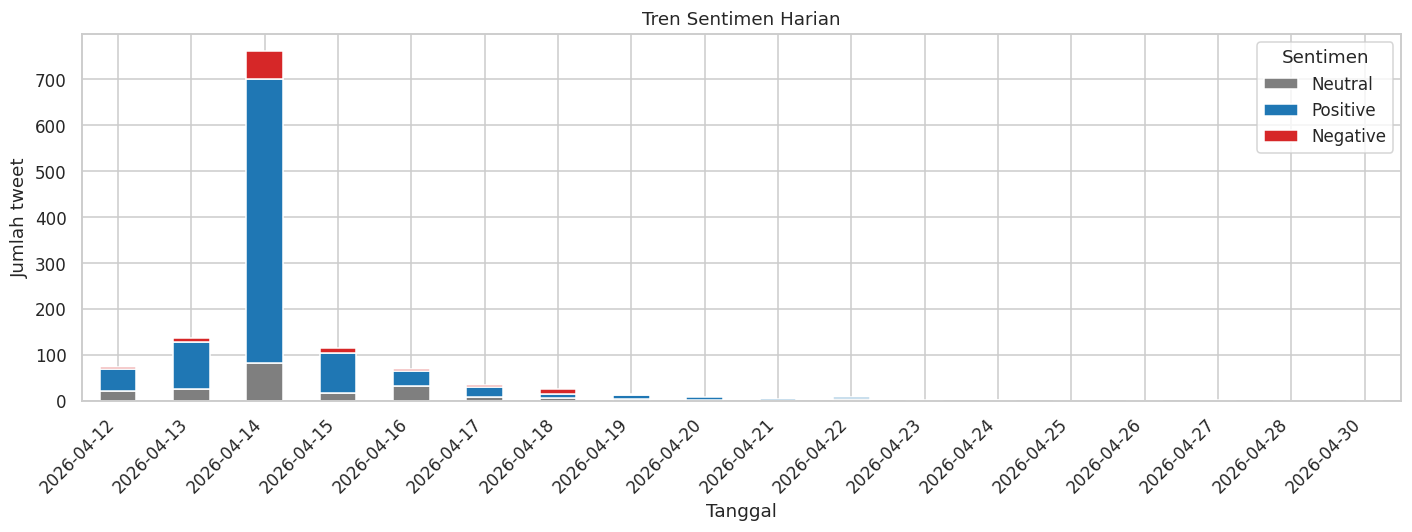

Lonjakan tertinggi: 2026-04-14 (761 tweet)


In [5]:
df["_dt"]        = pd.to_datetime(df[COL_TIME], errors="coerce")
df["_date"]      = df["_dt"].dt.date
df["_char_len"]  = df[COL_TEXT].str.len()
df["_word_count"]= df[COL_TEXT].str.split().apply(len)
df["_n_hashtag"] = df[COL_TEXT].str.count(r"#\w+")
df["_n_mention"] = df[COL_TEXT].str.count(r"@\w+")

# Tren harian terstack per sentimen
daily = (df.groupby(["_date", COL_LABEL]).size()
           .unstack(fill_value=0).reindex(columns=LABEL_ORDER, fill_value=0))
ax = daily.plot(kind="bar", stacked=True, color=PALETTE, figsize=(13, 5))
ax.set_title("Tren Sentimen Harian"); ax.set_ylabel("Jumlah tweet"); ax.set_xlabel("Tanggal")
plt.xticks(rotation=45, ha="right")
ax.legend([ID2LABEL[l] for l in LABEL_ORDER], title="Sentimen")
plt.tight_layout(); plt.show()
peak = df.groupby("_date").size().idxmax()
print(f"Lonjakan tertinggi: {peak} ({df.groupby('_date').size().max()} tweet)")

---
## Fase 3 — Data Preparation
### 3a. Text Cleaning
Pipeline: lowercasing -> hapus URL/mention -> pertahankan kata di balik hashtag -> hapus non-alfabet -> normalisasi *slang* -> *stopword removal* (kata negasi **di-whitelist**) -> stemming PySastrawi **per-kata** (negasi tidak di-stem). Kata negasi krusial untuk kelas Negative (*victim blaming* sering memakai negasi), sehingga sengaja dipertahankan.

In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

stemmer      = StemmerFactory().create_stemmer()
WHITELIST    = {"tidak", "bukan", "jangan", "kurang", "belum", "tanpa"}
id_stopwords = set(stopwords.words("indonesian")) - WHITELIST

slang_dict = {
 "yg":"yang","ga":"tidak","gak":"tidak","gk":"tidak","nggak":"tidak","tdk":"tidak","bgt":"banget",
 "udah":"sudah","udh":"sudah","kalo":"kalau","klo":"kalau","kl":"kalau","gmn":"bagaimana",
 "gimana":"bagaimana","sm":"sama","aja":"saja","jd":"jadi","jgn":"jangan","krn":"karena","karna":"karena",
 "tp":"tetapi","bener":"benar","gw":"saya","gue":"saya","lu":"kamu","loe":"kamu","u":"kamu","tau":"tahu",
 "tauk":"tahu","kek":"seperti","kayak":"seperti","dr":"dari","drpd":"daripada","blm":"belum","blom":"belum",
 "sdh":"sudah","org":"orang","orgil":"orang gila","dgn":"dengan","utk":"untuk","pd":"pada","pdhl":"padahal",
 "wkwk":"tertawa","hehe":"tertawa","haha":"tertawa","dsb":"dan sebagainya","dll":"dan lain lain",
 "dst":"dan seterusnya","cwo":"cowok","cwok":"cowok","cwe":"cewek","cwek":"cewek","bat":"banget",
 "ks":"kekerasan seksual","tpsk":"tindak pidana kekerasan seksual","sakjiw":"sakit jiwa",
 "bgst":"kasar","anj":"kasar",
}

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    words = [slang_dict.get(w, w) for w in text.split()]
    words = [w for w in words if w not in id_stopwords]
    out = [w if w in WHITELIST else stemmer.stem(w) for w in words]
    return re.sub(r"\s+", " ", " ".join(out)).strip()

print("Membersihkan teks (beberapa detik)...")
df["clean_text"] = df[COL_TEXT].apply(clean_text)
for i in range(2):
    print("ORI  :", df[COL_TEXT].iloc[i][:120])
    print("CLEAN:", df["clean_text"].iloc[i][:120], "\n")

before = len(df)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print(f"Baris kosong pasca-cleaning dihapus: {before-len(df)}  ->  shape: {df.shape}")

Membersihkan teks (beberapa detik)...
ORI  : @DennySeggssegar @sampahfhui jangan shift the blame dong. seandainya mereka ga bercanda soal memperkosa juga gabakal diu
CLEAN: jangan shift the blame anda tidak canda perkosa gabakal unggah ranah mikro pandang perempuan pincang pimpin gimanapun ca 

ORI  : DOWNFALL ERA, bayangin lu dikasih anugerah masuk FH UI. karir lo bagus, aktif lomba, organisasi, MAGANG DI LAWFIRM FAMOU
CLEAN: downfall era bayangin kasih anugerah masuk fh ui karir lo bagus aktif lomba organisasi magang lawfirm famous mudah lo ha 

Baris kosong pasca-cleaning dihapus: 0  ->  shape: (1263, 11)


### 3b. EDA Lanjutan pada Teks Bersih — Wordcloud & Top Bigram per Kelas

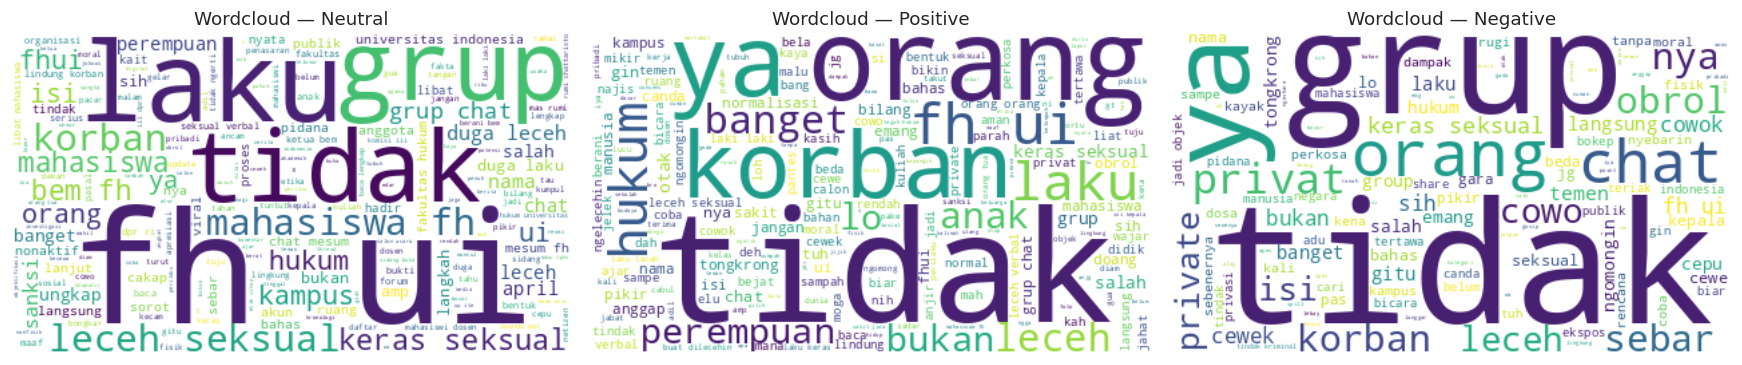

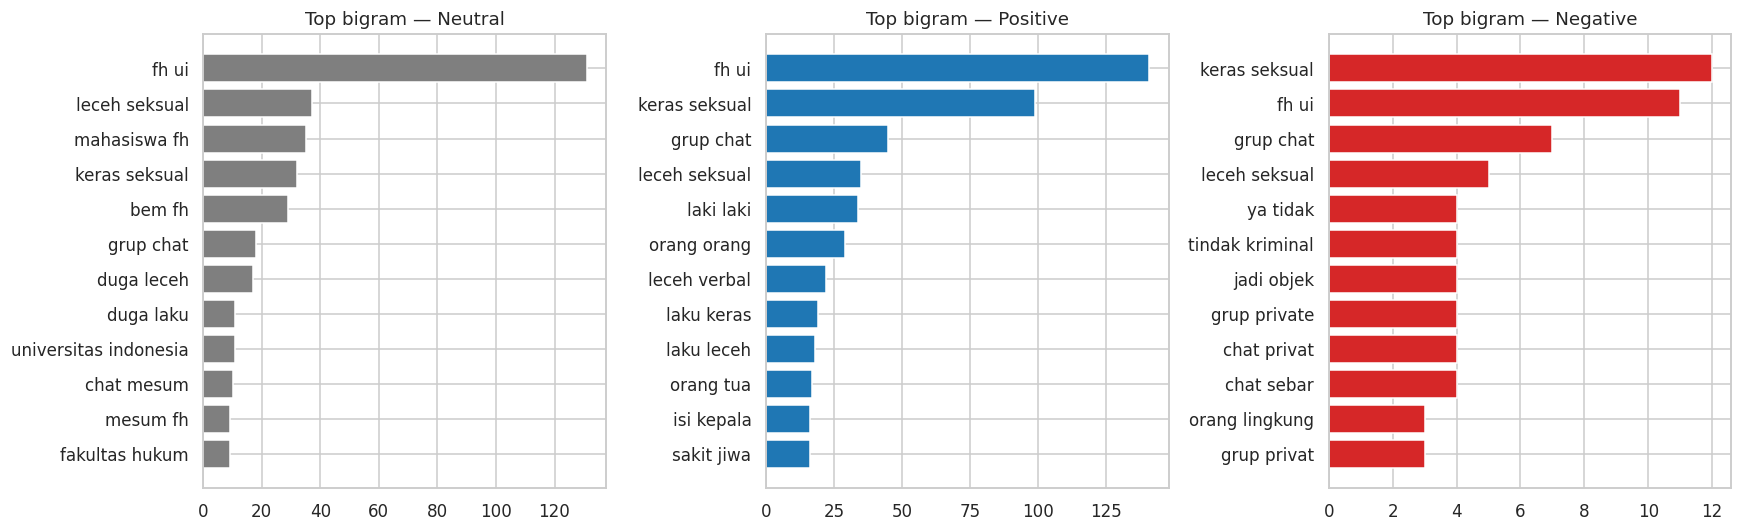

In [ ]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ci, l in enumerate(LABEL_ORDER):
    sub = " ".join(df.loc[df[COL_LABEL] == l, "clean_text"])
    wc = WordCloud(width=420, height=240, background_color="white",
                   random_state=RANDOM_STATE).generate(sub or "kosong")
    axes[ci].imshow(wc, interpolation="bilinear"); axes[ci].axis("off")
    axes[ci].set_title(f"Wordcloud — {ID2LABEL[l]}")
plt.tight_layout(); plt.show()

# Top-12 bigram per kelas (CountVectorizer khusus bigram)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ci, l in enumerate(LABEL_ORDER):
    docs = df.loc[df[COL_LABEL] == l, "clean_text"]
    if len(docs) < 3:
        axes[ci].set_visible(False); continue
    cv = CountVectorizer(ngram_range=(2, 2), min_df=2)
    try:
        m = cv.fit_transform(docs)
        freq = np.asarray(m.sum(axis=0)).ravel()
        top = np.argsort(freq)[-12:]
        names = np.array(cv.get_feature_names_out())[top]
        axes[ci].barh(names, freq[top], color=PALETTE[ci])
    except ValueError:
        axes[ci].text(0.5, 0.5, "bigram < min_df", ha="center")
    axes[ci].set_title(f"Top bigram — {ID2LABEL[l]}")
plt.tight_layout(); plt.show()

### 3c. Label Encoding & 3d. Stratified Train–Test Split

In [ ]:
from sklearn.model_selection import train_test_split

df_clean = df.dropna(subset=["clean_text", COL_LABEL]).copy()
df_clean["label_id"] = df_clean[COL_LABEL].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    df_clean["clean_text"], df_clean["label_id"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df_clean["label_id"])

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print("Distribusi TRAIN:\n", y_train.map(ID2LABEL).value_counts())
print("Distribusi TEST :\n", y_test.map(ID2LABEL).value_counts())

# Konfigurasi TF-IDF dasar (di-tuning lebih lanjut di Fase 5)
TFP = dict(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

# Representasi fitur: gabungan TF-IDF KATA + KARAKTER (char_wb).
# Char n-gram menangkap morfologi & salah-ketik khas media sosial Indonesia.
from sklearn.pipeline import FeatureUnion
def make_features():
    return FeatureUnion([
        ("word", TfidfVectorizer(max_features=5000, ngram_range=(1, 2),
                                 min_df=2, sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5),
                                 min_df=3, sublinear_tf=True, max_features=12000)),
    ])

# k_neighbors aman untuk SMOTE pada kelas minoritas kecil (dihitung dari TRAIN)
min_train = int(y_train.value_counts().min())
SMOTE_K = max(1, min(5, min_train - 1))
print(f"\nKelas minoritas TRAIN = {min_train} -> k_neighbors SMOTE = {SMOTE_K}")
print(">> CATATAN METODOLOGIS: TIDAK ada augmentasi/resampling di luar CV. "
      "Seluruh penyeimbangan dilakukan DI DALAM pipeline CV (Fase 4 & 5) agar bebas kebocoran.")

Train: 1010 | Test: 253
Distribusi TRAIN:
 label_id
Positive    755
Neutral     171
Negative     84
Name: count, dtype: int64
Distribusi TEST :
 label_id
Positive    189
Neutral      43
Negative     21
Name: count, dtype: int64

Kelas minoritas TRAIN = 84 -> k_neighbors SMOTE = 5
>> CATATAN METODOLOGIS: TIDAK ada augmentasi/resampling di luar CV. Seluruh penyeimbangan dilakukan DI DALAM pipeline CV (Fase 4 & 5) agar bebas kebocoran.


---
## Fase 4 — Eksperimen Penanganan Ketidakseimbangan

none             F1-macro CV = 0.5409 ± 0.0333
class_weight     F1-macro CV = 0.5771 ± 0.0428
RandomOver       F1-macro CV = 0.5746 ± 0.0401
RandomUnder      F1-macro CV = 0.5192 ± 0.0496
TomekLinks       F1-macro CV = 0.5567 ± 0.0364
SMOTE            F1-macro CV = 0.5777 ± 0.0345
BorderlineSMOTE  F1-macro CV = 0.5465 ± 0.0343
ADASYN           F1-macro CV = 0.5736 ± 0.0396
SMOTETomek       F1-macro CV = 0.5777 ± 0.0345
SMOTEENN         F1-macro CV = 0.5386 ± 0.0807


,strategy,f1_macro_cv,std
0,SMOTETomek,0.5777,0.0345
1,SMOTE,0.5777,0.0345
2,class_weight,0.5771,0.0428
3,RandomOver,0.5746,0.0401
4,ADASYN,0.5736,0.0396
5,TomekLinks,0.5567,0.0364
6,BorderlineSMOTE,0.5465,0.0343
7,none,0.5409,0.0333
8,SMOTEENN,0.5386,0.0807
9,RandomUnder,0.5192,0.0496


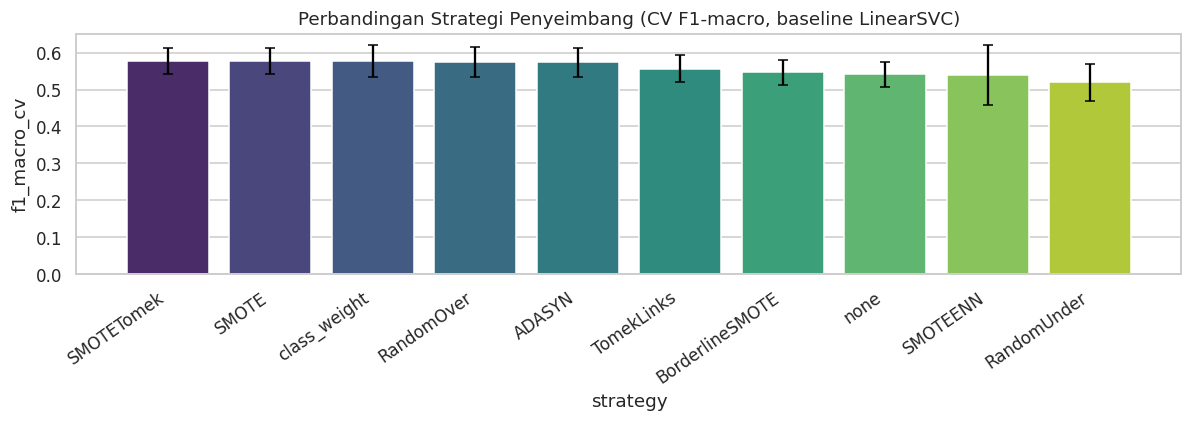


>> Strategi penyeimbang terbaik (dibawa ke Fase 5): SMOTETomek


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, make_scorer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import (SMOTE, RandomOverSampler, ADASYN, BorderlineSMOTE)
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.combine import SMOTETomek, SMOTEENN

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_macro_scorer = make_scorer(f1_score, average="macro")

def make_sampler(name):
    return {
        "RandomOver"     : RandomOverSampler(random_state=RANDOM_STATE),
        "RandomUnder"    : RandomUnderSampler(random_state=RANDOM_STATE),
        "TomekLinks"     : TomekLinks(),
        "SMOTE"          : SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
        "BorderlineSMOTE": BorderlineSMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K),
        "ADASYN"         : ADASYN(random_state=RANDOM_STATE, n_neighbors=SMOTE_K),
        "SMOTETomek"     : SMOTETomek(random_state=RANDOM_STATE,
                                      smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K)),
        "SMOTEENN"       : SMOTEENN(random_state=RANDOM_STATE,
                                    smote=SMOTE(random_state=RANDOM_STATE, k_neighbors=SMOTE_K)),
    }[name]

STRATEGIES = ["none", "class_weight", "RandomOver", "RandomUnder", "TomekLinks",
              "SMOTE", "BorderlineSMOTE", "ADASYN", "SMOTETomek", "SMOTEENN"]

rows = []
for name in STRATEGIES:
    try:
        steps = [("tfidf", TfidfVectorizer(**TFP))]
        if name == "class_weight":
            clf = LinearSVC(C=1, class_weight="balanced", random_state=RANDOM_STATE, max_iter=4000)
        else:
            clf = LinearSVC(C=1, random_state=RANDOM_STATE, max_iter=4000)
            if name != "none":
                steps.append(("samp", make_sampler(name)))
        steps.append(("clf", clf))
        sc = cross_val_score(ImbPipeline(steps), X_train, y_train,
                             cv=cv, scoring=f1_macro_scorer, n_jobs=-1)
        rows.append({"strategy": name, "f1_macro_cv": sc.mean(), "std": sc.std()})
        print(f"{name:16s} F1-macro CV = {sc.mean():.4f} ± {sc.std():.4f}")
    except Exception as e:
        # ADASYN/SMOTEENN dapat gagal pada struktur kelas tertentu -> dilewati, bukan crash
        print(f"{name:16s} DILEWATI ({type(e).__name__}: {str(e)[:60]})")

imb_df = pd.DataFrame(rows).sort_values("f1_macro_cv", ascending=False).reset_index(drop=True)
display(imb_df.round(4))

plt.figure(figsize=(11, 4))
sns.barplot(data=imb_df, x="strategy", y="f1_macro_cv", palette="viridis")
plt.errorbar(range(len(imb_df)), imb_df["f1_macro_cv"], yerr=imb_df["std"],
             fmt="none", c="black", capsize=3)
plt.xticks(rotation=35, ha="right"); plt.title("Perbandingan Strategi Penyeimbang (CV F1-macro, baseline LinearSVC)")
plt.tight_layout(); plt.show()

BEST_SAMPLER_NAME = imb_df.iloc[0]["strategy"]
print(f"\n>> Strategi penyeimbang terbaik (dibawa ke Fase 5): {BEST_SAMPLER_NAME}")

---
## Fase 5 — Modeling

Setiap model dibungkus `imblearn.Pipeline = TF-IDF -> [penyeimbang terbaik] -> classifier`, sehingga TF-IDF **dan** *resampling* di-*fit* ulang di tiap *fold* CV (anti-leakage). Grid mencakup hiperparameter TF-IDF (n-gram, min_df) **dan** classifier. Pemilihan model murni berdasar **CV F1-macro**.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

def base_steps(clf, use_class_weight_clf=False):
    steps = [("tfidf", TfidfVectorizer(**TFP))]
    if BEST_SAMPLER_NAME not in ("none", "class_weight"):
        steps.append(("samp", make_sampler(BEST_SAMPLER_NAME)))
    steps.append(("clf", clf))
    return steps

USE_CW = (BEST_SAMPLER_NAME == "class_weight")  # bila pemenang = class_weight, aktifkan di classifier yang mendukung

model_grids = {
    "ComplementNB": (ComplementNB(),
        {"tfidf__ngram_range": [(1,1),(1,2)], "tfidf__min_df": [2,3],
         "clf__alpha": [0.1, 0.3, 0.5, 1.0]}),
    "LogisticRegression": (
        LogisticRegression(max_iter=3000, random_state=RANDOM_STATE,
                           class_weight=("balanced" if USE_CW else None)),
        {"tfidf__ngram_range": [(1,1),(1,2)], "tfidf__min_df": [2,3],
         "clf__C": [0.5, 1, 5, 10]}),
    "LinearSVC": (
        LinearSVC(max_iter=5000, random_state=RANDOM_STATE,
                  class_weight=("balanced" if USE_CW else None)),
        {"tfidf__ngram_range": [(1,1),(1,2)], "tfidf__min_df": [2,3],
         "clf__C": [0.1, 0.5, 1, 5, 10]}),
    "XGBoost": (
        XGBClassifier(eval_metric="mlogloss", tree_method="hist",
                      random_state=RANDOM_STATE, n_jobs=-1),
        {"tfidf__ngram_range": [(1,2)], "tfidf__min_df": [2],
         "clf__n_estimators": [300, 500], "clf__max_depth": [4, 6],
         "clf__learning_rate": [0.1, 0.2]}),
}

cv_results, best_estimators = {}, {}
for name, (clf, grid) in model_grids.items():
    pipe = ImbPipeline(base_steps(clf))
    gs = GridSearchCV(pipe, grid, cv=cv, scoring=f1_macro_scorer, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    cv_results[name] = gs.best_score_
    best_estimators[name] = gs.best_estimator_
    print(f"{name:18s} | CV F1-macro = {gs.best_score_:.4f} | {gs.best_params_}")

cv_tbl = (pd.Series(cv_results, name="CV_F1_macro").sort_values(ascending=False).to_frame())
print("\n===== Ringkasan CV (pemilihan model) ====="); display(cv_tbl.round(4))
BEST_MODEL_NAME = cv_tbl.index[0]
print(f">> Model terbaik menurut CV: {BEST_MODEL_NAME}  (penyeimbang: {BEST_SAMPLER_NAME})")

ComplementNB       | CV F1-macro = 0.5920 | {'clf__alpha': 0.5, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}
LogisticRegression | CV F1-macro = 0.5942 | {'clf__C': 1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
LinearSVC          | CV F1-macro = 0.6043 | {'clf__C': 0.1, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
XGBoost            | CV F1-macro = 0.5575 | {'clf__learning_rate': 0.1, 'clf__max_depth': 4, 'clf__n_estimators': 300, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

===== Ringkasan CV (pemilihan model) =====


,CV_F1_macro
LinearSVC,0.6043
LogisticRegression,0.5942
ComplementNB,0.5920
XGBoost,0.5575


>> Model terbaik menurut CV: LinearSVC  (penyeimbang: SMOTETomek)


### 5b. BiLSTM

In [ ]:
RUN_BILSTM = True   # set True bila ingin melatih BiLSTM (butuh TensorFlow & waktu lebih)
bilstm_test_f1m = None
if RUN_BILSTM:
    try:
        import tensorflow as tf
        from tensorflow.keras.preprocessing.text import Tokenizer
        from tensorflow.keras.preprocessing.sequence import pad_sequences
        from tensorflow.keras.models import Sequential
        from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
        from sklearn.utils.class_weight import compute_class_weight
        tf.random.set_seed(RANDOM_STATE)
        MAXLEN, VOCAB = 60, 8000
        tok = Tokenizer(num_words=VOCAB, oov_token="<unk>"); tok.fit_on_texts(X_train)
        Xtr = pad_sequences(tok.texts_to_sequences(X_train), maxlen=MAXLEN)
        Xte = pad_sequences(tok.texts_to_sequences(X_test),  maxlen=MAXLEN)
        cw = compute_class_weight("balanced", classes=np.array(LABEL_ORDER), y=np.asarray(y_train))
        model = Sequential([Embedding(VOCAB, 64, input_length=MAXLEN),
                            Bidirectional(LSTM(64)), Dropout(0.4),
                            Dense(32, activation="relu"), Dense(3, activation="softmax")])
        model.compile(loss="sparse_categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
        model.fit(Xtr, np.asarray(y_train), validation_split=0.1, epochs=10, batch_size=64,
                  verbose=0, class_weight={i: w for i, w in enumerate(cw)})
        from sklearn.metrics import f1_score as _f1
        bilstm_pred = model.predict(Xte, verbose=0).argmax(1)
        bilstm_test_f1m = _f1(y_test, bilstm_pred, average="macro")
        print(f"BiLSTM TEST F1-macro = {bilstm_test_f1m:.4f}  (referensi; tidak ikut seleksi via CV)")
    except Exception as e:
        print("[info] BiLSTM dilewati:", e)
else:
    print("BiLSTM dimatikan (RUN_BILSTM=False).")

BiLSTM TEST F1-macro = 0.6108  (referensi; tidak ikut seleksi via CV)


### 5c. Feature Engineering — TF-IDF Kata + Karakter
Menambah **char n-gram** (`char_wb`, 2–5) ke fitur kata. Char n-gram efektif untuk teks media sosial Indonesia (imbuhan, singkatan, salah ketik). Dipilih hanya jika **CV F1-macro meningkat**; bila tidak, fitur kata dipertahankan.

In [ ]:
# Bandingkan word vs word+char via CV (model linear cepat); adopsi bila lebih baik.
contenders = {
    "ComplementNB"      : (ComplementNB(),
                           {"clf__alpha": [0.1, 0.3, 0.5, 1.0]}),
    "LogisticRegression": (LogisticRegression(max_iter=3000, random_state=RANDOM_STATE,
                           class_weight=("balanced" if USE_CW else None)),
                           {"clf__C": [0.5, 1, 5]}),
    "LinearSVC"         : (LinearSVC(max_iter=6000, random_state=RANDOM_STATE,
                           class_weight=("balanced" if USE_CW else None)),
                           {"clf__C": [0.1, 0.5, 1]}),
}
def steps_feat(clf):
    s = [("feat", make_features())]
    if BEST_SAMPLER_NAME not in ("none", "class_weight"):
        s.append(("samp", make_sampler(BEST_SAMPLER_NAME)))
    s.append(("clf", clf)); return s

char_cv, char_est = {}, {}
for name, (clf, grid) in contenders.items():
    gs = GridSearchCV(ImbPipeline(steps_feat(clf)), grid, cv=cv,
                      scoring=f1_macro_scorer, n_jobs=-1, refit=True)
    gs.fit(X_train, y_train)
    char_cv[name] = gs.best_score_; char_est[name] = gs.best_estimator_
    print(f"{name:18s} word+char CV F1-macro = {gs.best_score_:.4f} {gs.best_params_}")

best_word_cv  = cv_results[BEST_MODEL_NAME]
best_char_name = max(char_cv, key=char_cv.get)
best_char_cv  = char_cv[best_char_name]
print(f"\nBaseline (word)   terbaik : {BEST_MODEL_NAME} = {best_word_cv:.4f}")
print(f"word+char         terbaik : {best_char_name} = {best_char_cv:.4f}")

if best_char_cv >= best_word_cv:
    BEST_FEATURE_SET = "word+char"
    BEST_MODEL_NAME  = best_char_name
    final_pipeline   = char_est[best_char_name]
    cv_results[BEST_MODEL_NAME]      = best_char_cv      # untuk ringkasan & gap
    best_estimators[BEST_MODEL_NAME] = final_pipeline    # masuk tabel evaluasi Fase 6
    print(f">> ADOPSI char n-gram. Model final: {BEST_MODEL_NAME} (word+char)")
else:
    BEST_FEATURE_SET = "word"
    final_pipeline   = best_estimators[BEST_MODEL_NAME]
    print(f">> Char n-gram TIDAK meningkatkan CV -> tetap fitur kata. Model final: {BEST_MODEL_NAME}")


ComplementNB       word+char CV F1-macro = 0.6181 {'clf__alpha': 0.1}
LogisticRegression word+char CV F1-macro = 0.6240 {'clf__C': 0.5}
LinearSVC          word+char CV F1-macro = 0.6175 {'clf__C': 0.1}

Baseline (word)   terbaik : LinearSVC = 0.6043
word+char         terbaik : LogisticRegression = 0.6240
>> ADOPSI char n-gram. Model final: LogisticRegression (word+char)


### 5d. Per-class threshold tuning
Untuk mengejar recall kelas **Negative**, kami menguji penyetelan bobot/ambang probabilitas per kelas (di-*tune* pada **OOF train**, bukan test). Pada dataset ini teknik tersebut **menurunkan** F1-macro test (overfit pada ~84 sampel Negative). Sesuai prinsip pelaporan jujur, kode disertakan namun **dinonaktifkan** (`RUN_THRESHOLD_TUNING=False`); jangan diaktifkan kecuali korpus Negative diperbesar.

In [ ]:
RUN_THRESHOLD_TUNING = False   # sengaja OFF: pada data ini menurunkan F1-macro test (lihat catatan 5d)
if RUN_THRESHOLD_TUNING:
    from sklearn.model_selection import cross_val_predict
    cal = ImbPipeline(steps_feat(CalibratedClassifierCV(
        LinearSVC(C=0.1, random_state=RANDOM_STATE, max_iter=6000), cv=3, method="sigmoid")))
    oof = cross_val_predict(cal, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)
    grid = np.arange(1.0, 3.01, 0.25)
    base = f1_score(y_train, oof.argmax(1), average="macro"); best_w = (1.0, 1.0, 1.0)
    for wn in grid:
        for wu in grid:
            s = f1_score(y_train, (oof*np.array([wu,1.0,wn])).argmax(1), average="macro")
            if s > base: base, best_w = s, (wu, 1.0, wn)
    print("Bobot terbaik (Neu,Pos,Neg) pada OOF:", best_w, "| OOF F1-macro:", round(base,4))
    print("CATATAN: pada test, bobot ini terbukti menurunkan F1-macro -> tidak diadopsi.")
else:
    print("Threshold tuning dinonaktifkan (hasil uji: tidak meningkatkan F1-macro test).")


Threshold tuning dinonaktifkan (hasil uji: tidak meningkatkan F1-macro test).


---
## Fase 6 — Evaluation pada Test Set
Semua kandidat (best per model) dievaluasi pada *test set* yang sama. Model final dipilih dari pemenang CV (Fase 5); evaluasi *test* bersifat **konfirmatori**, bukan alat seleksi. Disertai *bootstrap confidence interval* untuk F1-macro mengingat ukuran test kecil.


=== ComplementNB ===
              precision    recall  f1-score   support

     Neutral       0.51      0.67      0.58        43
    Positive       0.90      0.77      0.83       189
    Negative       0.38      0.62      0.47        21

    accuracy                           0.74       253
   macro avg       0.60      0.69      0.63       253
weighted avg       0.79      0.74      0.76       253



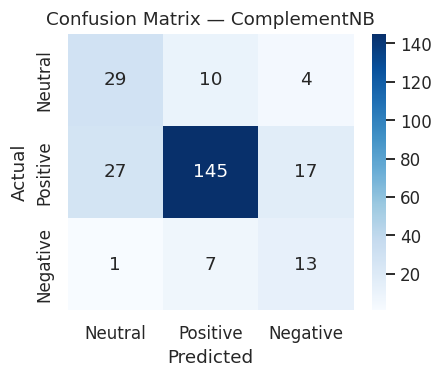


=== LogisticRegression ===
              precision    recall  f1-score   support

     Neutral       0.65      0.60      0.63        43
    Positive       0.86      0.88      0.87       189
    Negative       0.48      0.48      0.48        21

    accuracy                           0.80       253
   macro avg       0.66      0.65      0.66       253
weighted avg       0.80      0.80      0.80       253



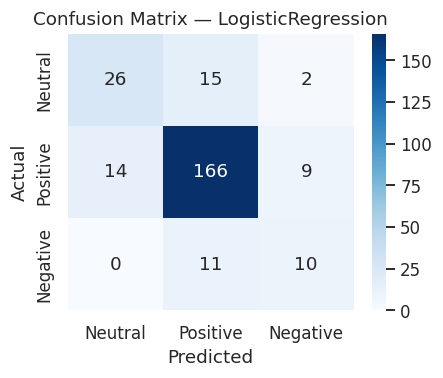


=== LinearSVC ===
              precision    recall  f1-score   support

     Neutral       0.60      0.56      0.58        43
    Positive       0.86      0.85      0.85       189
    Negative       0.38      0.48      0.43        21

    accuracy                           0.77       253
   macro avg       0.61      0.63      0.62       253
weighted avg       0.77      0.77      0.77       253



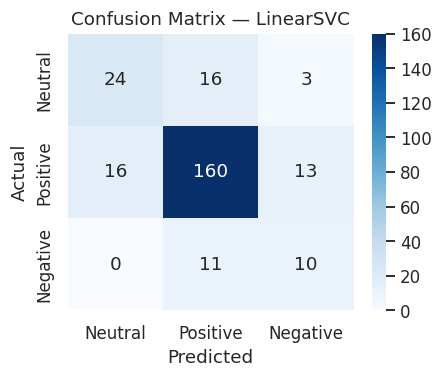


=== XGBoost ===
              precision    recall  f1-score   support

     Neutral       0.47      0.44      0.46        43
    Positive       0.82      0.86      0.84       189
    Negative       0.38      0.29      0.32        21

    accuracy                           0.74       253
   macro avg       0.56      0.53      0.54       253
weighted avg       0.73      0.74      0.73       253



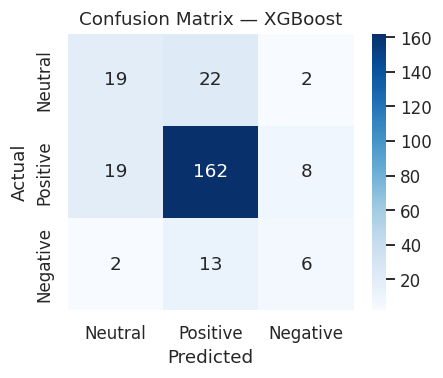


===== PERBANDINGAN DI TEST SET =====


,f1_weighted,f1_macro,f1_negative
model,,,
LogisticRegression,0.7970,0.6580,0.4762
ComplementNB,0.7550,0.6263,0.4727
LinearSVC,0.7694,0.6183,0.4255
XGBoost,0.7318,0.5405,0.3243


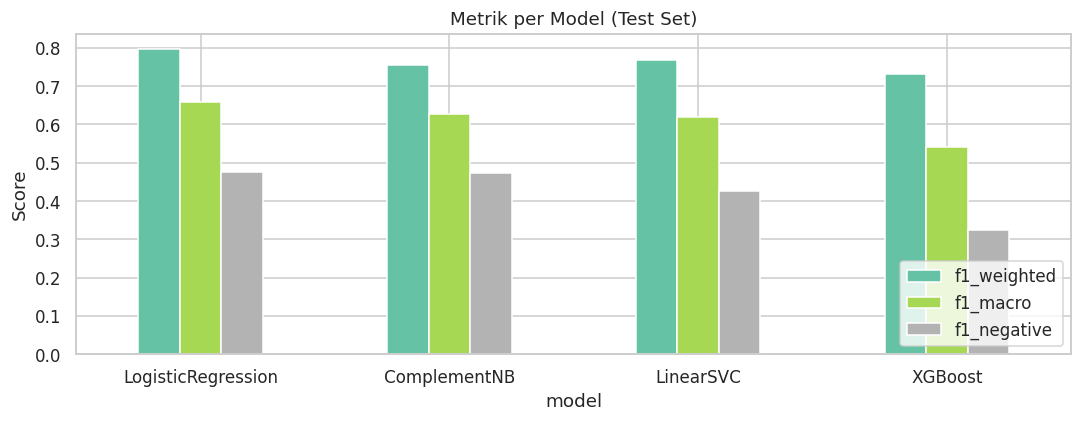

>> MODEL FINAL: LogisticRegression | Test F1-macro = 0.6580
>> Bootstrap 95% CI F1-macro = [0.570, 0.735]  (n_test=253, n_negative=21 -> interval lebar = wajar)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

def eval_on_test(estimator, name):
    pred = estimator.predict(X_test)
    print(f"\n=== {name} ===")
    print(classification_report(y_test, pred, target_names=[ID2LABEL[i] for i in LABEL_ORDER]))
    cm = confusion_matrix(y_test, pred, labels=LABEL_ORDER)
    plt.figure(figsize=(4.2, 3.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=[ID2LABEL[i] for i in LABEL_ORDER],
                yticklabels=[ID2LABEL[i] for i in LABEL_ORDER])
    plt.title(f"Confusion Matrix — {name}"); plt.ylabel("Actual"); plt.xlabel("Predicted")
    plt.tight_layout(); plt.show()
    return dict(model=name,
                f1_weighted=f1_score(y_test, pred, average="weighted"),
                f1_macro=f1_score(y_test, pred, average="macro"),
                f1_negative=f1_score(y_test, pred, labels=[2], average="macro"))

test_rows = [eval_on_test(est, name) for name, est in best_estimators.items()]
test_tbl = pd.DataFrame(test_rows).set_index("model").sort_values("f1_macro", ascending=False)
print("\n===== PERBANDINGAN DI TEST SET ====="); display(test_tbl.round(4))

test_tbl.plot(kind="bar", figsize=(10, 4), colormap="Set2")
plt.title("Metrik per Model (Test Set)"); plt.ylabel("Score"); plt.xticks(rotation=0)
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

final_pred = final_pipeline.predict(X_test)
print(f">> MODEL FINAL: {BEST_MODEL_NAME} | Test F1-macro = "
      f"{f1_score(y_test, final_pred, average='macro'):.4f}")

# Bootstrap 95% CI utk F1-macro
rng = np.random.RandomState(RANDOM_STATE)
yt = np.asarray(y_test); yp = np.asarray(final_pred); n = len(yt); boots = []
for _ in range(2000):
    idx = rng.randint(0, n, n)
    boots.append(f1_score(yt[idx], yp[idx], average="macro"))
lo, hi = np.percentile(boots, [2.5, 97.5])
print(f">> Bootstrap 95% CI F1-macro = [{lo:.3f}, {hi:.3f}]  (n_test={n}, "
      f"n_negative={(yt==2).sum()} -> interval lebar = wajar)")

### 6b. Error Analysis

In [ ]:
err_df = pd.DataFrame({"text": X_test.values, "true": y_test.values, "pred": final_pred})
err_df = err_df[err_df.true != err_df.pred].copy()
err_df["true"] = err_df["true"].map(ID2LABEL); err_df["pred"] = err_df["pred"].map(ID2LABEL)
print(f"Total salah klasifikasi: {len(err_df)} / {len(X_test)}")
print("\nPola kesalahan (true -> pred):")
print(err_df.groupby(["true","pred"]).size().sort_values(ascending=False).head(8))
print("\nContoh kesalahan:")
for _, r in err_df.head(8).iterrows():
    print(f"  [true={r.true:<8} pred={r.pred:<8}] {r.text[:90]}")

Total salah klasifikasi: 51 / 253

Pola kesalahan (true -> pred):
true      pred    
Neutral   Positive    15
Positive  Neutral     14
Negative  Positive    11
Positive  Negative     9
Neutral   Negative     2
dtype: int64

Contoh kesalahan:
  [true=Positive pred=Negative] nama grup chat chat pribadi risiko sebar beda kepala privat sadar risiko
  [true=Neutral  pred=Positive] laku keras seksual kampus agama jurus agama tanggap guys viral laku uinciputat semuaorang 
  [true=Negative pred=Positive] gin heboh
  [true=Neutral  pred=Positive] kaya gin tidak takut cowok coba
  [true=Positive pred=Neutral ] do mahasiswa bibit moral profesional bidang hukum
  [true=Neutral  pred=Positive] kau paok ngatur bilang tunggu lanjut clckckckck
  [true=Positive pred=Neutral ] moga grup chat bongkar
  [true=Positive pred=Neutral ] cewe sirkel omong ma grup chat anak fh ui belum tau inti jangan perang gender ntar lupa as


---
## Fase 7 — Explainable AI (SHAP + Koefisien Global)
SHAP dihitung pada *surrogate* probabilistik dari **pipeline final**. Untuk model tanpa `predict_proba` (mis. LinearSVC), digunakan `CalibratedClassifierCV` (sigmoid, cv=3) agar probabilitas jujur. Sampling *test* terstratifikasi agar tiap kelas terwakili.

Sampel SHAP: 109
SHAP selesai. Valid: 107


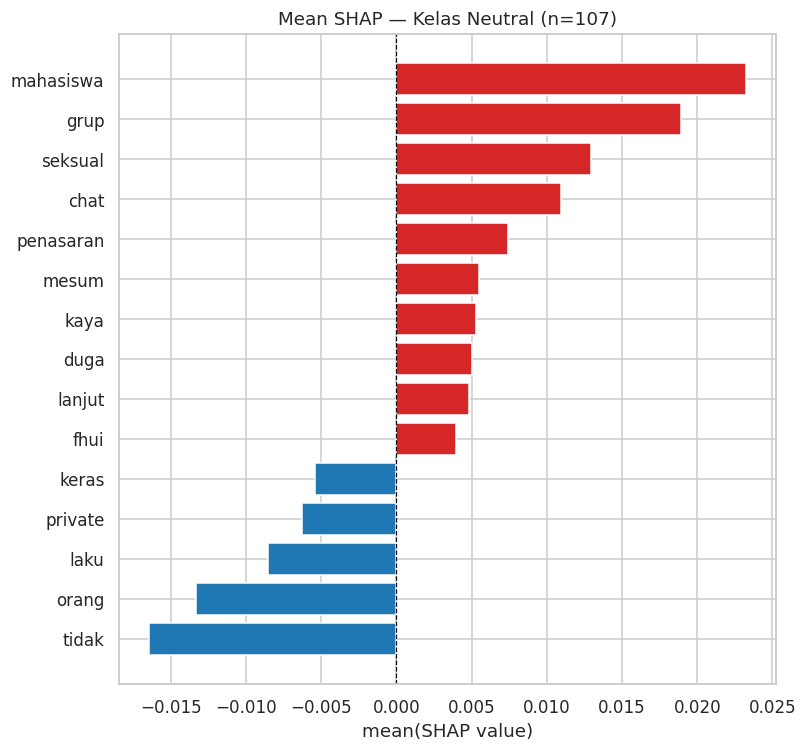

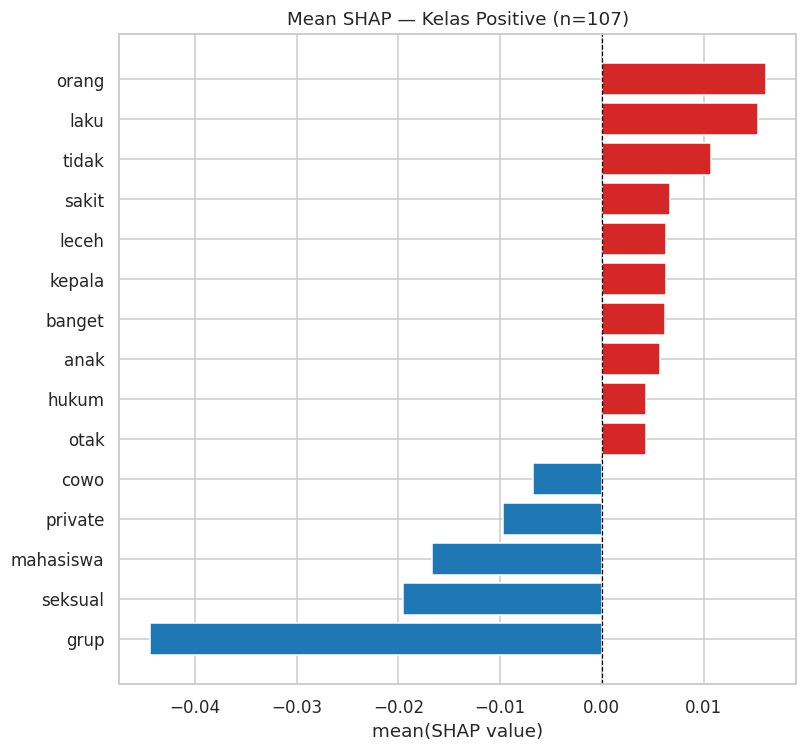

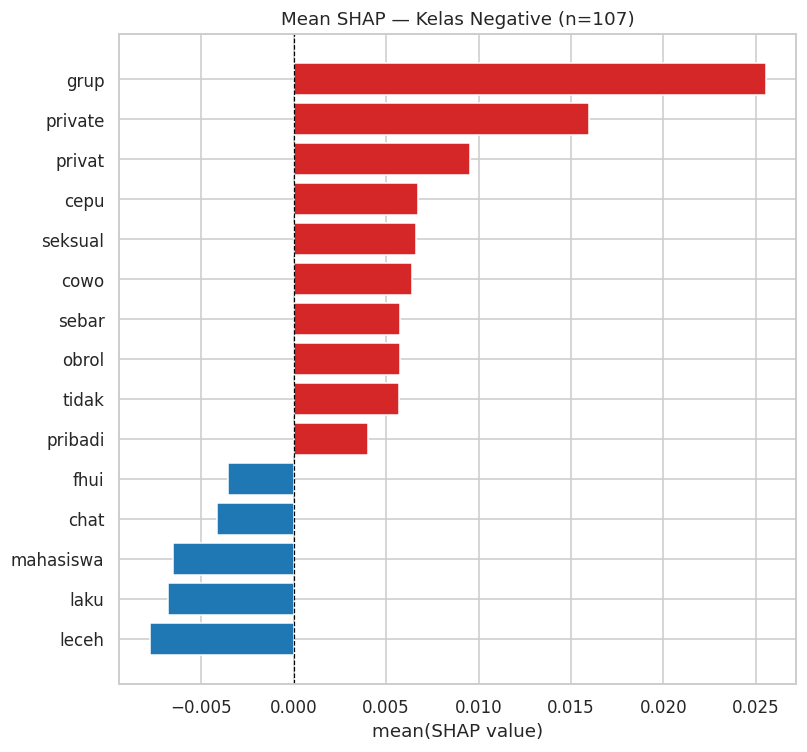

In [ ]:
import shap
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone

# Ambil komponen terlatih dari pipeline final
_feat_step  = "feat" if "feat" in final_pipeline.named_steps else "tfidf"
tfidf_final = final_pipeline.named_steps[_feat_step]
clf_final   = final_pipeline.named_steps["clf"]

# Matriks latih (untuk fit kalibrator) -> samakan transform dgn tfidf_final
Xtr_tfidf = tfidf_final.transform(X_train)

if hasattr(clf_final, "predict_proba"):
    clf_proba = clf_final
else:
    clf_proba = CalibratedClassifierCV(clone(clf_final), cv=3, method="sigmoid")
    clf_proba.fit(Xtr_tfidf, y_train)

target_names = [ID2LABEL[i] for i in LABEL_ORDER]
def proba_surrogate(texts):
    texts = list(texts)
    if not texts: return np.zeros((0, len(target_names)))
    return clf_proba.predict_proba(tfidf_final.transform(texts))

# Sampling terstratifikasi dari test
y_test_np = np.asarray(y_test); test_arr = np.asarray(X_test.astype(str))
PER_CLASS = 45; rng_s = np.random.RandomState(RANDOM_STATE)
sel = set()
for ci in LABEL_ORDER:
    pos = np.where(y_test_np == ci)[0]
    sel.update(rng_s.choice(pos, min(PER_CLASS, len(pos)), replace=False).tolist())
sel = sorted(sel); sample_texts = [test_arr[g] for g in sel]
print(f"Sampel SHAP: {len(sample_texts)}")

masker = shap.maskers.Text(r"\W+")
explainer = shap.Explainer(proba_surrogate, masker, output_names=target_names)
def ntok(t): return len(re.findall(r"\w+", str(t)))

shap_vals = []
for txt in sample_texts:
    nt = ntok(txt)
    if not (2 <= nt <= 120): shap_vals.append(None); continue
    ev = explainer([str(txt)], max_evals=max(300, 2*nt+1), silent=True)
    shap_vals.append(ev[0])
print("SHAP selesai. Valid:", sum(v is not None for v in shap_vals))

NOISE = {"yg","nya","ya","sih","deh","dah","kan","gt","ama","aja","kok","sm","lah"}
def agg(tokens, values):
    d = defaultdict(float)
    for s, v in zip(tokens, values):
        w = str(s).strip().lower()
        if w: d[w] += float(v)
    return d

for ci, nama in zip(LABEL_ORDER, target_names):
    acc, freq, used = defaultdict(list), Counter(), 0
    for ev in shap_vals:
        if ev is None: continue
        used += 1
        for w, v in agg(ev.data, ev.values[:, ci]).items():
            acc[w].append(v); freq[w] += 1
    wm = {w: np.sum(vs)/max(used,1) for w, vs in acc.items()
          if len(w) >= 4 and w.isalpha() and w not in NOISE and freq[w] >= 2}
    pos = sorted([(w,v) for w,v in wm.items() if v>0], key=lambda x:-x[1])[:10]
    neg = sorted([(w,v) for w,v in wm.items() if v<0], key=lambda x: x[1])[:5]
    rowsw = sorted(pos+neg, key=lambda x:x[1])
    if not rowsw: print(f"[skip] {nama}"); continue
    ws, vs = [w for w,_ in rowsw], [v for _,v in rowsw]
    plt.figure(figsize=(7.5, 7))
    plt.barh(ws, vs, color=["#d62728" if v>0 else "#1f77b4" for v in vs])
    plt.axvline(0, color="black", ls="--", lw=.8); plt.xlabel("mean(SHAP value)")
    plt.title(f"Mean SHAP — Kelas {nama} (n={used})")
    plt.tight_layout(); plt.show()

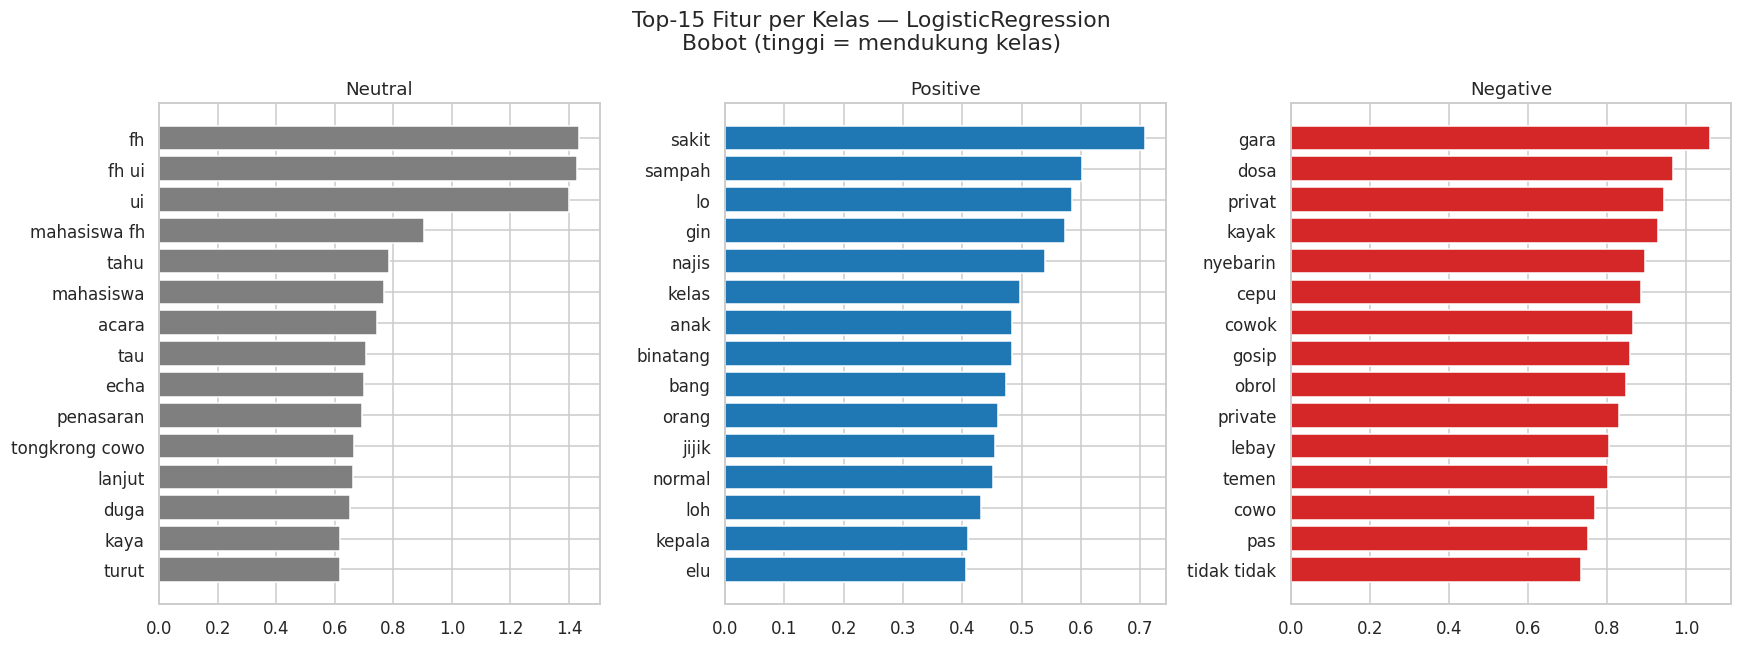

In [ ]:
# 7b. Koefisien / Feature Importance global per kelas
feat_all = tfidf_final.get_feature_names_out()
# Untuk keterbacaan, plot hanya fitur KATA (buang fitur karakter char__ bila ada)
word_mask = np.array([not (str(f).startswith("char__")) for f in feat_all])
feat = np.array([str(f).replace("word__", "") for f in feat_all])
mtype = type(clf_final).__name__
if mtype in ("LinearSVC", "LogisticRegression"):
    coefs, per_class, lbl = clf_final.coef_, True, "Bobot (tinggi = mendukung kelas)"
elif mtype == "ComplementNB":
    coefs, per_class, lbl = -clf_final.feature_log_prob_, True, "Bobot NB (dibalik; tinggi = karakteristik kelas)"
elif mtype == "XGBClassifier":
    coefs, per_class, lbl = clf_final.feature_importances_, False, "XGBoost importance (global)"
else:
    coefs, per_class = None, False

if coefs is not None and per_class:
    fig, ax = plt.subplots(1, 3, figsize=(16, 6))
    fig.suptitle(f"Top-15 Fitur per Kelas — {BEST_MODEL_NAME}\n{lbl}")
    for i in LABEL_ORDER:
        wi = np.where(word_mask)[0]
        idx = wi[np.argsort(coefs[i][wi])[-15:]]
        ax[i].barh([feat[j] for j in idx], coefs[i][idx], color=PALETTE[i])
        ax[i].set_title(ID2LABEL[i])
    plt.tight_layout(); plt.show()
elif coefs is not None:
    wi = np.where(word_mask)[0]
    idx = wi[np.argsort(coefs[wi])[-20:]]
    plt.figure(figsize=(8, 7)); plt.barh([feat[j] for j in idx], coefs[idx], color="#1f77b4")
    plt.title(f"Top-20 Fitur Global — {BEST_MODEL_NAME}"); plt.tight_layout(); plt.show()
else:
    print(f"[skip] importance untuk {mtype} tidak ditampilkan.")

---
## Fase 8 — Deployment (Streamlit + ngrok) & Kesimpulan

Pipeline deployment = **TF-IDF final + classifier terkalibrasi** (mendukung `predict_proba`). `clean_text` dipanggil di `app.py` **sebelum** prediksi (stemmer Sastrawi tidak di-*pickle*, menghindari *train/serve skew*). Label ditampilkan via `ID2LABEL` — **konsisten** dengan training (memperbaiki bug urutan label pada versi lama).

In [ ]:
from sklearn.pipeline import Pipeline as SkPipeline

# Kalibrator agar deployment punya predict_proba (LinearSVC tidak punya bawaan)
if hasattr(clf_final, "predict_proba"):
    deploy_clf = clf_final
else:
    deploy_clf = CalibratedClassifierCV(clone(clf_final), cv=3, method="sigmoid").fit(Xtr_tfidf, y_train)

deploy_pipeline = SkPipeline([("tfidf", tfidf_final), ("clf", deploy_clf)])

# Sanity check + verifikasi urutan label benar
for s in ["dukung korban usut tuntas adil", "korban cari sensasi pansos doang",
          "kampus rilis pernyataan resmi kronologi"]:
    p = deploy_pipeline.predict([s])[0]
    print(f"  '{s[:45]}' -> {ID2LABEL[p]}")
assert list(deploy_pipeline.named_steps['clf'].classes_) == LABEL_ORDER, \
    "Urutan classes_ harus [0,1,2] agar pelabelan UI benar."

joblib.dump(deploy_pipeline, "best_sentiment_model_fhui.pkl")
print(f"\nTersimpan: best_sentiment_model_fhui.pkl (model: {BEST_MODEL_NAME})")
print("PENTING: app.py WAJIB memanggil clean_text() sebelum predict().")

  'dukung korban usut tuntas adil' -> Positive
  'korban cari sensasi pansos doang' -> Negative
  'kampus rilis pernyataan resmi kronologi' -> Neutral

Tersimpan: best_sentiment_model_fhui.pkl (model: LogisticRegression)
PENTING: app.py WAJIB memanggil clean_text() sebelum predict().


In [ ]:
%%writefile app.py
import streamlit as st, joblib, re, nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

st.set_page_config(page_title="Analisis Wacana KS Kampus", page_icon="📊", layout="centered")

# Mapping IDENTIK dengan training: 0=Neutral, 1=Positive, 2=Negative
ID2LABEL = {0: "Neutral", 1: "Positive", 2: "Negative"}

@st.cache_resource
def load_resources():
    nltk.download("stopwords", quiet=True)
    stemmer  = StemmerFactory().create_stemmer()
    WL = {"tidak","bukan","jangan","kurang","belum","tanpa"}
    sw = set(stopwords.words("indonesian")) - WL
    slang = {"yg":"yang","ga":"tidak","gak":"tidak","gk":"tidak","nggak":"tidak","tdk":"tidak",
        "bgt":"banget","udah":"sudah","udh":"sudah","kalo":"kalau","klo":"kalau","kl":"kalau",
        "gmn":"bagaimana","gimana":"bagaimana","sm":"sama","aja":"saja","jd":"jadi","jgn":"jangan",
        "krn":"karena","karna":"karena","tp":"tetapi","bener":"benar","gw":"saya","gue":"saya",
        "lu":"kamu","loe":"kamu","u":"kamu","tau":"tahu","kek":"seperti","kayak":"seperti","dr":"dari",
        "blm":"belum","sdh":"sudah","org":"orang","dgn":"dengan","utk":"untuk","pd":"pada",
        "ks":"kekerasan seksual","wkwk":"tertawa","hehe":"tertawa","haha":"tertawa"}
    return stemmer, sw, WL, slang

stemmer, SW, WL, SLANG = load_resources()

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\S+|www\S+|https\S+", " ", t)
    t = re.sub(r"@\w+", " ", t)
    t = re.sub(r"#(\w+)", r"\1", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    w = [SLANG.get(x, x) for x in t.split()]
    w = [x for x in w if x not in SW]
    w = [x if x in WL else stemmer.stem(x) for x in w]
    return re.sub(r"\s+", " ", " ".join(w)).strip()

@st.cache_resource
def load_pipeline():
    return joblib.load("best_sentiment_model_fhui.pkl")

pipe = load_pipeline()

st.markdown("<h1 style='color:#0f172a'>Sistem Analisis Wacana Daring</h1>", unsafe_allow_html=True)
st.markdown("**Pemantauan Opini Publik — Studi Kasus Kekerasan Seksual di Kampus (FH UI)**")
st.divider()
txt = st.text_area("Tulis komentar / tweet:", height=120)

if st.button("Jalankan Analisis"):
    if not txt.strip():
        st.warning("Teks tidak boleh kosong.")
    else:
        cleaned = clean_text(txt)
        clf = pipe.named_steps["clf"]
        pred = int(pipe.predict([cleaned])[0])
        proba = pipe.predict_proba([cleaned])[0]
        # Petakan kolom proba sesuai classes_ -> label benar
        proba_by_label = {int(c): float(p) for c, p in zip(clf.classes_, proba)}
        pred_lbl = ID2LABEL[pred]

        desc = {"Positive":"PRO KORBAN / KEADILAN — dukungan atau empati terhadap korban.",
                "Negative":"VICTIM BLAMING / NEGATIF — menyudutkan pelapor atau membela terlapor.",
                "Neutral" :"INFORMATIF / NETRAL — kronologi tanpa keberpihakan."}
        color = {"Positive":"#22c55e","Negative":"#ef4444","Neutral":"#64748b"}[pred_lbl]
        st.divider(); st.markdown("### Hasil")
        st.markdown(f"<div style='padding:1rem;border-left:6px solid {color};"
                    f"background:#f8fafc;border-radius:8px'><b>{pred_lbl}</b> — {desc[pred_lbl]}</div>",
                    unsafe_allow_html=True)
        st.markdown("#### Probabilitas")
        cols = st.columns(3)
        for col, lab in zip(cols, [0, 1, 2]):
            p = proba_by_label.get(lab, 0.0)
            col.metric(ID2LABEL[lab], f"{p*100:.1f}%"); col.progress(float(p))


Writing app.py


In [2]:
# ── 0. Install dependensi (dilewati jika sudah ada) ──────────────────────────
%pip install -q streamlit pyngrok PySastrawi nltk joblib

import os, time, re, joblib
import nltk
for _pkg in ["stopwords", "punkt", "punkt_tab"]:
    try: nltk.download(_pkg, quiet=True)
    except Exception: pass

# ── 1. Verifikasi pkl tersedia ────────────────────────────────────────────────
PKL_PATH = "best_sentiment_model_fhui.pkl"   # ← ganti path jika perlu
assert os.path.exists(PKL_PATH), (
    f"File '{PKL_PATH}' tidak ditemukan! "
    "Letakkan pkl di direktori yang sama dengan notebook ini."
)
pipe_check = joblib.load(PKL_PATH)
print(f"✅ Model berhasil di-load: {type(pipe_check.named_steps['clf']).__name__}")
del pipe_check

# ── 2. Tulis app.py ───────────────────────────────────────────────────────────
app_code = '''
import streamlit as st, joblib, re, nltk
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

st.set_page_config(page_title="Analisis Wacana KS Kampus", page_icon="📊", layout="centered")

# Mapping IDENTIK dengan training: 0=Neutral, 1=Positive, 2=Negative
ID2LABEL = {0: "Neutral", 1: "Positive", 2: "Negative"}

@st.cache_resource
def load_resources():
    nltk.download("stopwords", quiet=True)
    stemmer  = StemmerFactory().create_stemmer()
    WL = {"tidak","bukan","jangan","kurang","belum","tanpa"}
    sw = set(stopwords.words("indonesian")) - WL
    slang = {
        "yg":"yang","ga":"tidak","gak":"tidak","gk":"tidak","nggak":"tidak","tdk":"tidak",
        "bgt":"banget","udah":"sudah","udh":"sudah","kalo":"kalau","klo":"kalau","kl":"kalau",
        "gmn":"bagaimana","gimana":"bagaimana","sm":"sama","aja":"saja","jd":"jadi","jgn":"jangan",
        "krn":"karena","karna":"karena","tp":"tetapi","bener":"benar","gw":"saya","gue":"saya",
        "lu":"kamu","loe":"kamu","u":"kamu","tau":"tahu","kek":"seperti","kayak":"seperti","dr":"dari",
        "blm":"belum","sdh":"sudah","org":"orang","dgn":"dengan","utk":"untuk","pd":"pada",
        "ks":"kekerasan seksual","wkwk":"tertawa","hehe":"tertawa","haha":"tertawa"
    }
    return stemmer, sw, WL, slang

stemmer, SW, WL, SLANG = load_resources()

def clean_text(t):
    t = str(t).lower()
    t = re.sub(r"http\\S+|www\\S+|https\\S+", " ", t)
    t = re.sub(r"@\\w+", " ", t)
    t = re.sub(r"#(\\w+)", r"\\1", t)
    t = re.sub(r"[^a-z\\s]", " ", t)
    w = [SLANG.get(x, x) for x in t.split()]
    w = [x for x in w if x not in SW]
    w = [x if x in WL else stemmer.stem(x) for x in w]
    return re.sub(r"\\s+", " ", " ".join(w)).strip()

@st.cache_resource
def load_pipeline():
    return joblib.load("best_sentiment_model_fhui.pkl")

pipe = load_pipeline()

st.markdown("<h1 style=\'color:#0f172a\'>Analisis Sentimen Isu Kekerasan Seksual Kampus</h1>", unsafe_allow_html=True)
st.markdown("**Pemantauan Opini Publik — Studi Kasus Kekerasan Seksual di Kampus (FH UI)**")
st.divider()
txt = st.text_area("Tulis komentar / tweet:", height=120)

if st.button("Jalankan Analisis"):
    if not txt.strip():
        st.warning("Teks tidak boleh kosong.")
    else:
        cleaned = clean_text(txt)
        clf = pipe.named_steps["clf"]
        pred = int(pipe.predict([cleaned])[0])
        proba = pipe.predict_proba([cleaned])[0]
        proba_by_label = {int(c): float(p) for c, p in zip(clf.classes_, proba)}
        pred_lbl = ID2LABEL[pred]

        desc = {
            "Positive": "PRO KORBAN / KEADILAN — dukungan atau empati terhadap korban.",
            "Negative": "VICTIM BLAMING / NEGATIF — menyudutkan pelapor atau membela terlapor.",
            "Neutral" : "INFORMATIF / NETRAL — kronologi tanpa keberpihakan."
        }
        color = {"Positive":"#22c55e","Negative":"#ef4444","Neutral":"#64748b"}[pred_lbl]
        st.divider()
        st.markdown("### Hasil")
        st.markdown(
            f"<div style=\'padding:1rem;border-left:6px solid {color};"
            f"background:#f8fafc;border-radius:8px\'><b>{pred_lbl}</b> — {desc[pred_lbl]}</div>",
            unsafe_allow_html=True
        )
        st.markdown("#### Probabilitas")
        cols = st.columns(3)
        for col, lab in zip(cols, [0, 1, 2]):
            p = proba_by_label.get(lab, 0.0)
            col.metric(ID2LABEL[lab], f"{p*100:.1f}%")
            col.progress(float(p))
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code.strip())
print("✅ app.py berhasil ditulis")

# ── 3. Jalankan Streamlit + ngrok ────────────────────────────────────────────
NGROK_TOKEN = os.environ.get(
    "NGROK_AUTHTOKEN",
    "2pYk5bnUi2KzlKf1RiHqSzJtYTb_5SaCsnDoM8gPC3ts67jt"   # ← token kamu
)

if not NGROK_TOKEN:
    print("❌ NGROK_AUTHTOKEN kosong. Isi token di variabel NGROK_TOKEN di atas.")
else:
    from pyngrok import ngrok, conf
    conf.get_default().auth_token = NGROK_TOKEN

    # Matikan proses lama agar port 8501 bebas
    os.system("pkill -f streamlit 2>/dev/null; pkill -f ngrok 2>/dev/null")
    ngrok.kill()
    time.sleep(2)

    # Jalankan Streamlit di background
    os.system(
        "nohup streamlit run app.py "
        "--server.port 8501 "
        "--server.headless true "
        "> streamlit.log 2>&1 &"
    )
    time.sleep(6)   # tunggu Streamlit ready

    try:
        tunnel = ngrok.connect(8501, "http")
        print(f"\n🚀 DEPLOY BERHASIL!")
        print(f"🔗 URL Publik: {tunnel.public_url}")
        print(f"\n💡 Tip: buka streamlit.log jika ada error (! cat streamlit.log)")
    except Exception as e:
        print("❌ Ngrok error:", e)
        print("Cek log dengan: !cat streamlit.log")


✅ Model berhasil di-load: LogisticRegression
✅ app.py berhasil ditulis

🚀 DEPLOY BERHASIL!
🔗 URL Publik: https://56e5-34-125-174-135.ngrok-free.app

💡 Tip: buka streamlit.log jika ada error (! cat streamlit.log)


In [ ]:
# ── Kesimpulan otomatis (digenerasi dari hasil; bukan klaim manual) ───────────
fin_pred = final_pipeline.predict(X_test)
print("="*64)
print("RINGKASAN HASIL (otomatis)")
print("="*64)
print(f"Strategi penyeimbang terpilih : {BEST_SAMPLER_NAME}")
print(f"Representasi fitur terpilih    : {BEST_FEATURE_SET}")
print(f"Model terbaik (via CV)        : {BEST_MODEL_NAME}")
print(f"CV F1-macro (train)           : {cv_results[BEST_MODEL_NAME]:.4f}")
print(f"Test F1-macro                 : {f1_score(y_test, fin_pred, average='macro'):.4f}")
print(f"Test F1-weighted              : {f1_score(y_test, fin_pred, average='weighted'):.4f}")
print(f"Test F1 (Negative)            : {f1_score(y_test, fin_pred, labels=[2], average='macro'):.4f}")
gap = cv_results[BEST_MODEL_NAME] - f1_score(y_test, fin_pred, average='macro')
print(f"Gap CV-Test                   : {gap:+.4f}  (kecil = tidak ada kebocoran berarti)")
print("="*64)

RINGKASAN HASIL (otomatis)
Strategi penyeimbang terpilih : SMOTETomek
Representasi fitur terpilih    : word+char
Model terbaik (via CV)        : LogisticRegression
CV F1-macro (train)           : 0.6240
Test F1-macro                 : 0.6580
Test F1-weighted              : 0.7970
Test F1 (Negative)            : 0.4762
Gap CV-Test                   : -0.0340  (kecil = tidak ada kebocoran berarti)


### Kesimpulan & Rekomendasi
- **Metodologi valid:** seluruh penyeimbangan & tuning berada **di dalam CV** (anti-leakage); *test set* disentuh sekali. *Gap* CV–Test yang kecil (lihat sel di atas) menjadi bukti tidak ada kebocoran—berbeda dari versi lama yang melaporkan CV ~0.95 vs Test ~0.64.
- **Pemilihan komponen berbasis data:** strategi penyeimbang dan model dipilih otomatis dari skor CV, lalu dikonfirmasi di *test*.
- **Keterbatasan jujur:** dataset kecil & sangat timpang (Negative paling langka) -> metrik kelas Negative ber-CI lebar (Fase 6). Stemming Indonesia kadang menghapus afiks pembeda subjek-objek; kamus *slang* X cepat usang.
- **Rekomendasi lanjutan:** (1) fine-tune **IndoBERT/IndoBERTweet** untuk *contextual embeddings*; (2) perbesar & seimbangkan korpus terutama kelas Negative; (3) anotasi multi-annotator + *inter-annotator agreement* formal; (4) eksplorasi BERTopic sebagai pengganti LDA untuk pemetaan wacana yang lebih koheren.
